<a href="https://colab.research.google.com/github/MElsdk-lab/Biochar_forest_estimation/blob/main/Notebook_2_Forest_Area_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NOTEBOOK 2 — Forest Area Analysis & FAO Comparison
# University of Pittsburgh | Biochar Feedstock Methodology
# ============================================================

In [2]:
# ── CELL 1: Install Libraries ─────────────────────────────────────────────────
!pip install -q pandas matplotlib
print('✅ Libraries installed')

✅ Libraries installed


In [3]:
# ── CELL 2: clone repo if not already cloned ─────────────────────
import os
import getpass
import subprocess

if not os.path.exists('/content/Biochar_forest_estimation'):
    PAT = getpass.getpass('Enter PAT: ')
    !git config --global user.email "sdkmajd@gmail.com"
    !git config --global user.name "MElsdk-lab"
    subprocess.run(
        f'git clone https://{PAT}@github.com/MElsdk-lab/Biochar_forest_estimation.git',
        shell=True
    )

%cd /content/Biochar_forest_estimation/
!git fetch origin
!git reset --hard origin/main

DATA_folder = '/content/Biochar_forest_estimation/data/'

print('✅ Ready')

/content/Biochar_forest_estimation
From https://github.com/MElsdk-lab/Biochar_forest_estimation
   e9519d5..ce43c59  main       -> origin/main
HEAD is now at ce43c59 update results
✅ Ready


In [4]:
## ── CELL 3: import Libraries and results & data from GEE and FOA ─────────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from data_config import (build_country_lookup, FAO_LSIB_REGION, country_thresholds, state_thresholds,
                         fao_fra_2025_raw_data, FAO_name_fix,
                         americas_region, europe_region, africa_region, asia_region, near_east_region)


print('✅ Libraries imported')
print('✅ Data config loaded')


✅ Libraries imported
✅ Data config loaded


In [5]:
## ── CELL 4: establish total countries and US states results & data ─────────────────────────────────────────────────

#countries
countries_files = [os.path.join(DATA_folder, f"forest_area_{i}0.csv") for i in range(1, 6)]

country_total_forest_area = pd.concat([pd.read_csv(f) for f in countries_files],ignore_index=True)

country_total_forest_area=country_total_forest_area.rename(columns = {'country_na' :'country', 'sum' : 'area_Mha'})
country_total_forest_area.sort_values(by= ['country', 'threshold'], ascending=True, inplace=True)
country_total_forest_area=country_total_forest_area.groupby(['country', 'threshold'])['area_Mha'].sum().reset_index()

country_total_forest_area.to_csv(DATA_folder + 'country_total_forest_area.csv', index=False)

print(f'✅ Forest data loaded and saved with {int(len(country_total_forest_area)/len(country_thresholds))} rows')
#States

states_files = [os.path.join(DATA_folder, f"states_forest_area_{i}0.csv") for i in range(1, 6)]

states_total_forest_area = pd.concat([pd.read_csv(f) for f in states_files], ignore_index=True)

states_total_forest_area = states_total_forest_area.rename(columns={'NAME': 'state', 'sum': 'area_Mha'})
states_total_forest_area.sort_values(by=['state', 'threshold'], ascending=True, inplace=True)
states_total_forest_area = states_total_forest_area.groupby(['state', 'threshold'])['area_Mha'].sum().reset_index()
states_total_forest_area.to_csv(DATA_folder + 'states_total_forest_area.csv', index=False)

alaska_state_forest_area = states_total_forest_area[states_total_forest_area['state' ]== 'Alaska']
hawaii_state_forest_area = states_total_forest_area[states_total_forest_area['state' ]== 'Hawaii']

"""
correction of USA forest area since
USA is  considered as a  block of 48 contiguous states referred to as the conterminous states forms a belt of 7 828 016 km2 across the continent from the Atlantic Ocean to the Pacific Ocean
Alaska and Hawaii are included in the Oceania and Pacific region

even in LSIB dataset the US is about 48 contiguous states ( confirmed by showing the layer on the map)
"""


print(f'✅ Forest data loaded and saved with {int(len(states_total_forest_area)/len(state_thresholds))} rows')


✅ Forest data loaded and saved with 195 rows
✅ Forest data loaded and saved with 50 rows


In [6]:
usa_forest_area_gee = country_total_forest_area[country_total_forest_area['country'] == 'United States']

print(usa_forest_area_gee)
# Merge on threshold so subtraction is aligned
usa = usa_forest_area_gee.set_index('threshold')
alaska = alaska_state_forest_area.set_index('threshold').rename(columns={'area_Mha': 'alaska_area_Mha'})
hawaii = hawaii_state_forest_area.set_index('threshold').rename(columns={'area_Mha': 'hawaii_area_Mha'})

merge = usa.merge(alaska, left_on='threshold', right_on='threshold').merge(hawaii, left_on='threshold', right_on='threshold')
#substract

merge['area_Mha'] = merge['area_Mha'] + (merge['alaska_area_Mha'] + merge['hawaii_area_Mha'])

merge=merge.drop(columns=['state_x', 'alaska_area_Mha', 'state_y','hawaii_area_Mha'])
merge = merge.reset_index()  # ADD THIS LINE

1
# Remove old US rows
country_total_forest_area_no_us = country_total_forest_area[country_total_forest_area['country'] != 'United States']

# Add adjusted US rows back
country_total_forest_area_cor= pd.concat([country_total_forest_area_no_us, merge], ignore_index=True)

country_total_forest_area_cor.to_csv(DATA_folder + 'country_total_forest_area_cor.csv', index=False)
print(f'✅ Adjusted USA forest area')

usa_forest_area_gee_cor = country_total_forest_area_cor[country_total_forest_area_cor['country'] == 'United States']


           country  threshold    area_Mha
925  United States         10  258.339230
926  United States         20  242.557391
927  United States         30  229.310219
928  United States         40  218.853025
929  United States         50  207.240547
✅ Adjusted USA forest area


In [7]:
## ── CELL 5 : build region and subregion info for countries in 'country_total_forest_area' file by the intermidate of FAO_LSIB_REGION   ─────────────────────────────────────────────────
# 1. Generate the lookup dictionary
country_lookup = build_country_lookup(FAO_LSIB_REGION)

# 2. Create the new columns by looking up each country name
# we could actualy transform the country_lookup from a dictionary to a data frame then merge with df bsed onthe country name
country_total_forest_area_cor['region'] = country_total_forest_area_cor['country'].map(lambda l: country_lookup.get(l, {}).get('region', 'unknown'))
country_total_forest_area_cor['subregion'] = country_total_forest_area_cor['country'].map(lambda l: country_lookup.get(l, {}).get('subregion', 'unknown'))

print(f"✅countries are affilited to regions and subregions")

✅countries are affilited to regions and subregions


In [11]:
# ── CELL 6: Merge GEE results with FAO 2000 ──────────────
FAO_fra_2025_data = pd.read_csv(DATA_folder + 'fao_fra_2025_data.csv')

FAO_forest_area_country_2000 = FAO_fra_2025_data[['country', '2000_area_Mha']].rename(columns={'2000_area_Mha': 'FAO_2000_Mha'})

gee_fao_comparison = country_total_forest_area_cor.merge(FAO_forest_area_country_2000, on='country', how='left')

#print(gee_fao_comparison.head(40))

print(f"Results from GEE has {len(country_total_forest_area)}")

print(f"FAO has {len(FAO_forest_area_country_2000)}")
#counting th number of countries with data; since there is 5  different thresholds, nunique returns the number of unique values in the selected column:
print(f'Total countries: {gee_fao_comparison["country"].nunique()}')

# if mising, unique show the the values of unique values

missing = gee_fao_comparison[gee_fao_comparison['FAO_2000_Mha'].isna()]['country'].unique()

print(f"Total countries with no FAO match: {len(missing)}")
print('GEE results are merged with FAO 2000 ')

usa_forest_area_gee_fao = gee_fao_comparison[gee_fao_comparison['country'] == 'United States']
print(usa_forest_area_gee_fao)

Results from GEE has 975
FAO has 195
Total countries: 195
Total countries with no FAO match: 0
GEE results are merged with FAO 2000 
           country  threshold    area_Mha    region      subregion  \
970  United States         10  315.888204  Americas  North America   
971  United States         20  296.005725  Americas  North America   
972  United States         30  280.179830  Americas  North America   
973  United States         40  265.610296  Americas  North America   
974  United States         50  244.861741  Americas  North America   

     FAO_2000_Mha  
970       303.536  
971       303.536  
972       303.536  
973       303.536  
974       303.536  


In [12]:
# ── CELL 7: aggregate by subregion and region. ──────────────

#subregion
gee_fao_comparison_subregion = gee_fao_comparison.groupby(['subregion', 'threshold']).agg(
    region=('region', 'first'), # Ensure 'region' is carried over
    subregion_total_forest_area=('area_Mha', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()


# add Alaska and Hawaii to world forest area to the pacific subregion

pacific_subregion = gee_fao_comparison_subregion[gee_fao_comparison_subregion['subregion'] == 'Pacific Region'].copy()
merged_pacific_subregion = pacific_subregion.merge(alaska, left_on='threshold', right_on='threshold').merge(hawaii, left_on='threshold', right_on='threshold')
merged_pacific_subregion['subregion_total_forest_area'] = merged_pacific_subregion['subregion_total_forest_area'] + (merged_pacific_subregion['alaska_area_Mha'] + merged_pacific_subregion['hawaii_area_Mha'])
merged_pacific_subregion = merged_pacific_subregion.drop(columns=['state_x', 'alaska_area_Mha', 'state_y','hawaii_area_Mha'])


#gee_fao_comparison_subregion_no_pacific = gee_fao_comparison_subregion[gee_fao_comparison_subregion['subregion'] != 'Pacific Region']
#gee_fao_comparison_subregion = pd.concat([gee_fao_comparison_subregion_no_pacific, merged_pacific_subregion])


#region
gee_fao_comparison_region = gee_fao_comparison_subregion.groupby(['region', 'threshold']).agg(
    region_total_forest_area=('subregion_total_forest_area', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()

#world
gee_fao_comparison_world = gee_fao_comparison_region.groupby(['threshold']).agg(
    world_total_forest_area=('region_total_forest_area', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()


#calucate the deviation between GEE and FOA
gee_fao_comparison['deviation_Mha'] = gee_fao_comparison['area_Mha'] - gee_fao_comparison['FAO_2000_Mha']
gee_fao_comparison['deviation_%'] = abs(gee_fao_comparison['deviation_Mha'] / gee_fao_comparison['FAO_2000_Mha']) * 100
gee_fao_comparison.replace([np.inf, -np.inf], np.nan, inplace=True)

clean_dev = gee_fao_comparison.replace([float('inf'), float('-inf')], float('nan'))

gee_fao_comparison_subregion['deviation_Mha'] = gee_fao_comparison_subregion['subregion_total_forest_area'] - gee_fao_comparison_subregion['FAO_2000_Mha']
gee_fao_comparison_subregion['deviation_%'] = abs(gee_fao_comparison_subregion['deviation_Mha'] / gee_fao_comparison_subregion['FAO_2000_Mha']) * 100

gee_fao_comparison_region['deviation_Mha'] = gee_fao_comparison_region['region_total_forest_area'] - gee_fao_comparison_region['FAO_2000_Mha']
gee_fao_comparison_region['deviation_%'] = abs(gee_fao_comparison_region['deviation_Mha'] / gee_fao_comparison_region['FAO_2000_Mha']) * 100

gee_fao_comparison_world['deviation_Mha'] = gee_fao_comparison_world['world_total_forest_area'] - gee_fao_comparison_world['FAO_2000_Mha']
gee_fao_comparison_world['deviation_%'] = abs(gee_fao_comparison_world['deviation_Mha'] / gee_fao_comparison_world['FAO_2000_Mha']) * 100

gee_fao_comparison.to_csv(DATA_folder + 'gee_fao_comparison.csv', index=False)
gee_fao_comparison_subregion.to_csv(DATA_folder + 'gee_fao_comparison_subregion.csv', index=False)
gee_fao_comparison_region.to_csv(DATA_folder + 'gee_fao_comparison_region.csv', index=False)
gee_fao_comparison_world.to_csv(DATA_folder + 'gee_fao_comparison_world.csv', index=False)

print('✅ Results are aggregated by subregion and region')

✅ Results are aggregated by subregion and region


In [13]:
#percentils of FAO forst area

percentiles = [25, 50, 60, 70, 80, 90, 95]
FAO_2000_percentiles = np.percentile(FAO_forest_area_country_2000['FAO_2000_Mha'],percentiles)

# Corrected dictionary creation: keys now match percentile values, and float() cast is removed as redundant
FAO_2000_percentiles_dict = {f'p{i}': round(v, 1) for i, v in zip(percentiles, FAO_2000_percentiles)}

# extract the values of the percentiles
x_p25 = int(FAO_2000_percentiles_dict['p25'])
x_p50 = int(FAO_2000_percentiles_dict['p50'])
x_p60 = int(FAO_2000_percentiles_dict['p60'])
x_p70 = int(FAO_2000_percentiles_dict['p70'])
x_p80 = int(FAO_2000_percentiles_dict['p80'])
x_p90 = int(FAO_2000_percentiles_dict['p90'])
x_p95 = int(FAO_2000_percentiles_dict['p95'])

# Corrected loop to iterate through percentile values and print corresponding dictionary values
for i in percentiles:
  key = f'p{i}'
  print(f'{i}% of countries have less than {float(FAO_2000_percentiles_dict[key])} Mha of forest')

#divide the foret area into bins and assing labels and colors
FAO_forest_area_country_2000_bins = FAO_forest_area_country_2000.copy()

bins= pd.cut(FAO_forest_area_country_2000_bins['FAO_2000_Mha'], bins=[0,x_p60, x_p90, np.inf], labels = ['Low (< 4 Mha)', 'Medium (4-37 Mha)', 'High (> 37 Mha)'])


#define colors
colors = {'Low (< 4 Mha)': '#4C9BE8',
          'Medium (4-37 Mha)' : '#F4A83A',
          'High (> 37 Mha)': '#F44336'
          }

FAO_forest_area_country_2000_bins['bin'] = bins

FAO_forest_area_country_2000_bins.to_csv(DATA_folder + 'FAO_forest_area_country_2000_bins.csv', index=False)

print(f'Countries remaining: {len(FAO_forest_area_country_2000_bins)}')


25% of countries have less than 0.4 Mha of forest
50% of countries have less than 2.6 Mha of forest
60% of countries have less than 4.0 Mha of forest
70% of countries have less than 8.2 Mha of forest
80% of countries have less than 16.0 Mha of forest
90% of countries have less than 37.3 Mha of forest
95% of countries have less than 70.9 Mha of forest
Countries remaining: 195


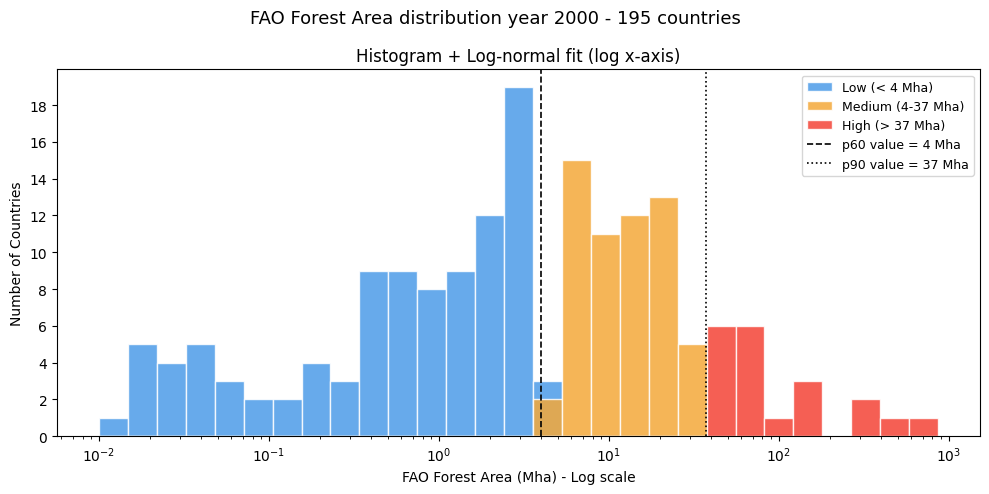

In [14]:

fig, ax = plt.subplots(figsize=(10, 5))

fig.suptitle('FAO Forest Area distribution year 2000 - 195 countries', fontsize=13)

x_values = FAO_forest_area_country_2000['FAO_2000_Mha'].values

# --- Fit log-normal on log of values ---
log_x_values = np.log10(x_values[x_values > 0])

mu, std = log_x_values.mean(), log_x_values.std()



# --- Plot 1: Histogram (log x-axis) + log-normal curve ---
stats_bins = []
for bin_label, bin_color in colors.items():
    subset = FAO_forest_area_country_2000_bins[FAO_forest_area_country_2000_bins['bin'] == bin_label]['FAO_2000_Mha']

    ax.hist(subset,
            bins= np.logspace(np.log10(0.01), np.log10(x_values.max() + 50),30),
            color = bin_color, edgecolor='white', alpha=0.85, label=bin_label, density=False)


# Log-normal curve

ax.axvline(x_p60, color = 'black', linestyle='--', linewidth = 1.2,  label = f'p60 value = {x_p60} Mha')
ax.axvline(x_p90, color = 'black', linestyle=':', linewidth = 1.2, label = f'p90 value = {x_p90} Mha')

ax.set_xscale('log')
ax.set_xlabel('FAO Forest Area (Mha) - Log scale')
ax.set_ylabel('Number of Countries')
ax.set_title('Histogram + Log-normal fit (log x-axis)')
ax.legend(fontsize = 9)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

"""
ax2 = ax.twinx()  # creates a second y-axis sharing the same x-axis

x_range = np.logspace(np.log10(0.01), np.log10(x_values.max() + 50), 300)
pdf = stats.lognorm.pdf(x_range, s=std, scale=10**mu)
ax2.plot(x_range, pdf, color='black', linewidth=2, linestyle='--', label='Log-normal fit')
ax2.set_ylabel('Density', color='black')
ax2.tick_params(axis='y', labelcolor='black')

"""

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
#l ines2, labels2 = ax2.get_legend_handles_labels()
#ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)


plt.tight_layout()
plt.show()

FAO consistently underestimates: 74 countries
FAO consistently overestimates: 66 countries
mixed countries: 55 countries


/tmp/ipykernel_89746/3671160845.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_bins_estimation = gee_fao_comparison_bins_estimation.groupby(['bin', 'estimation'])['country'].nunique()


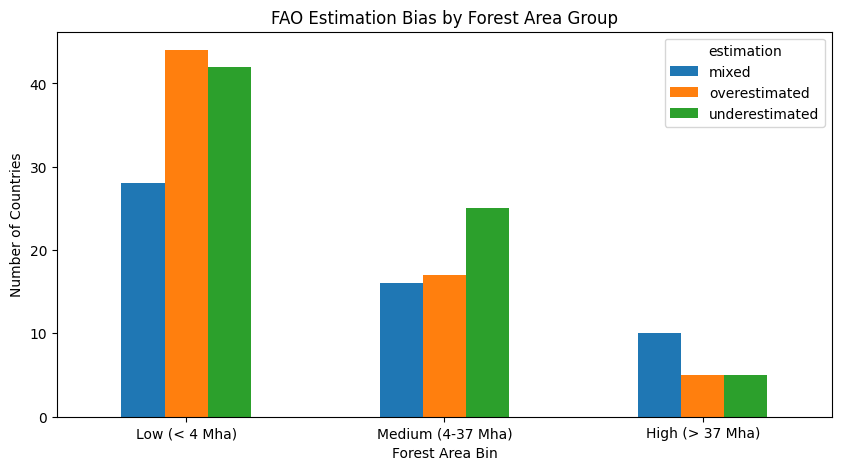

In [15]:
gee_fao_comparison_bins = gee_fao_comparison.merge(FAO_forest_area_country_2000_bins[['country', 'bin']], on= ['country'], how='left')
gee_fao_comparison_bins.to_csv(DATA_folder + 'gee_fao_comparison_bins.csv', index=False)


#see if the FOA undersimated by the deviaiton
estimation = gee_fao_comparison.groupby('country')['deviation_Mha']
underestimated = gee_fao_comparison.groupby('country')['deviation_Mha'].apply(lambda x: (x > 0).all()).reset_index(name='FAO_underestimates')

overestimated = gee_fao_comparison.groupby('country')['deviation_Mha'].apply(lambda x: (x < 0).all()).reset_index(name='FAO_overestimates')

print(f"FAO consistently underestimates: {underestimated['FAO_underestimates'].sum()} countries")
print(f"FAO consistently overestimates: {overestimated['FAO_overestimates'].sum()} countries")
print(f"mixed countries: {len(estimation) - underestimated['FAO_underestimates'].sum() - overestimated['FAO_overestimates'].sum()} countries")

gee_fao_comparison_bins_estimation = gee_fao_comparison_bins.merge(underestimated[['country', 'FAO_underestimates']], on= ['country'], how='left')
gee_fao_comparison_bins_estimation = gee_fao_comparison_bins_estimation.merge(overestimated[['country', 'FAO_overestimates']],  on= ['country'], how='left')

gee_fao_comparison_bins_estimation['mixed'] = (~gee_fao_comparison_bins_estimation['FAO_underestimates']) & (~gee_fao_comparison_bins_estimation['FAO_overestimates'])

conditions = [
    gee_fao_comparison_bins_estimation['FAO_underestimates'],
    gee_fao_comparison_bins_estimation['FAO_overestimates'],
    gee_fao_comparison_bins_estimation['mixed']
]

choices = ['underestimated', 'overestimated', 'mixed']

gee_fao_comparison_bins_estimation['estimation'] = np.select(conditions, choices, default='')

gee_fao_comparison_bins_estimation = gee_fao_comparison_bins_estimation.drop(columns=['FAO_underestimates', 'FAO_overestimates', 'mixed'])

gee_fao_comparison_bins_estimation.to_csv(DATA_folder + 'gee_fao_comparison_bins_estimation.csv', index=False)


country_bins_estimation = gee_fao_comparison_bins_estimation.groupby(['bin', 'estimation'])['country'].nunique()
country_bins_estimation.to_csv(DATA_folder + 'country_bins_estimation.csv', index= True)

country_bins_estimation.unstack()

fig, ax = plt.subplots(figsize=(10, 5))
country_bins_estimation.unstack().plot(kind='bar', ax=ax)

ax.set_xlabel('Forest Area Bin')
ax.set_ylabel('Number of Countries')
ax.set_title('FAO Estimation Bias by Forest Area Group')
ax.tick_params(axis='x', rotation=0)  # keeps x labels horizontal

/tmp/ipykernel_89746/2280756283.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = gee_fao_comparison_bins.groupby(['bin', 'threshold']).get_group((bin_label, threshold))


                  bin  threshold  r_squared  average deviation
0       Low (< 4 Mha)         10      0.521               57.8
1       Low (< 4 Mha)         20      0.614               51.0
2       Low (< 4 Mha)         30      0.683               49.2
3       Low (< 4 Mha)         40      0.690               48.6
4       Low (< 4 Mha)         50      0.665               49.2
5   Medium (4-37 Mha)         10      0.485               31.3
6   Medium (4-37 Mha)         20      0.508               28.7
7   Medium (4-37 Mha)         30      0.496               26.2
8   Medium (4-37 Mha)         40      0.486               22.8
9   Medium (4-37 Mha)         50      0.458               28.1
10    High (> 37 Mha)         10      0.972               24.0
11    High (> 37 Mha)         20      0.969               18.1
12    High (> 37 Mha)         30      0.967               24.4
13    High (> 37 Mha)         40      0.963               25.0
14    High (> 37 Mha)         50      0.952            

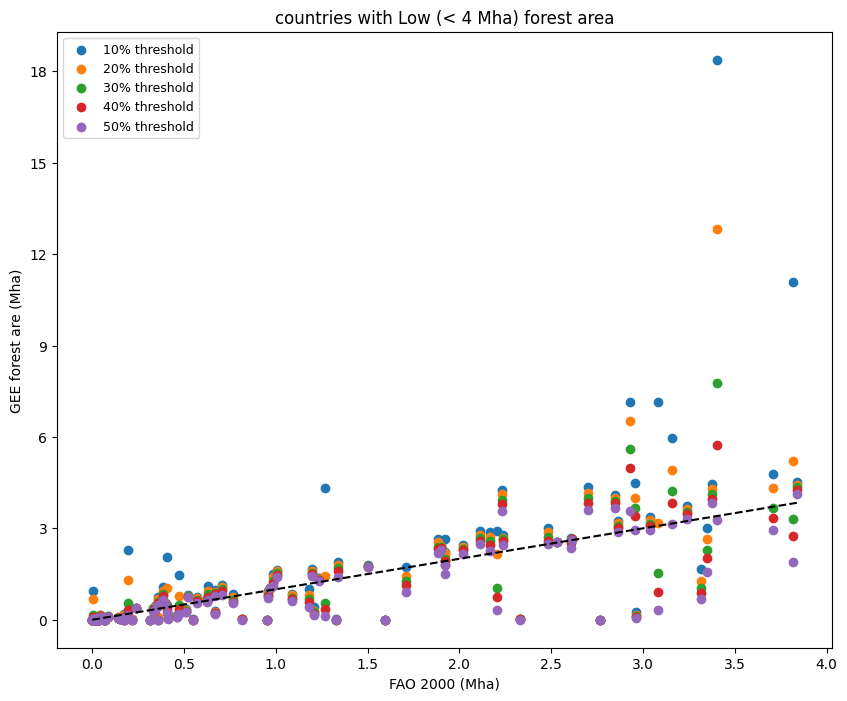

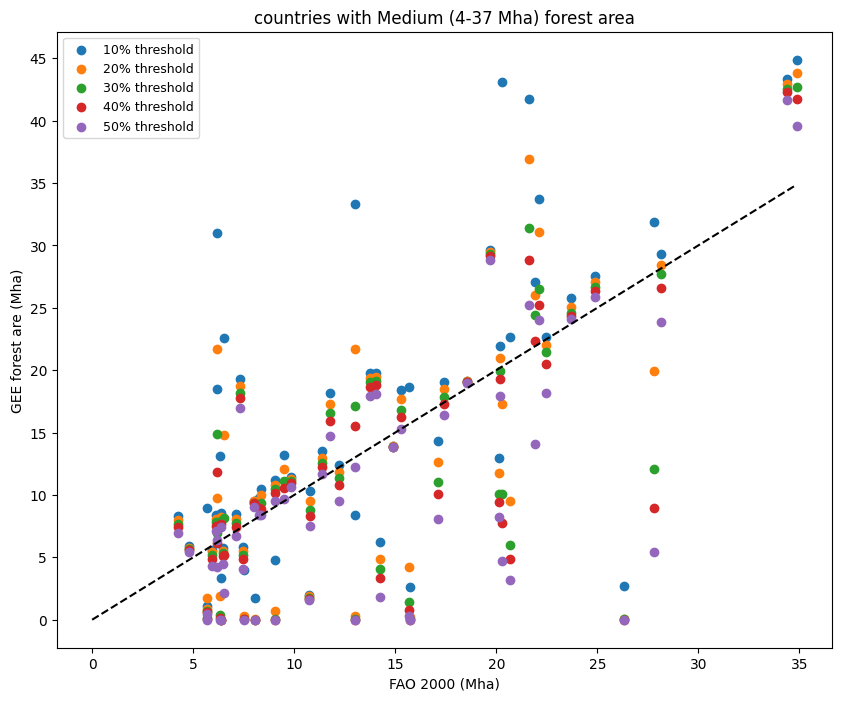

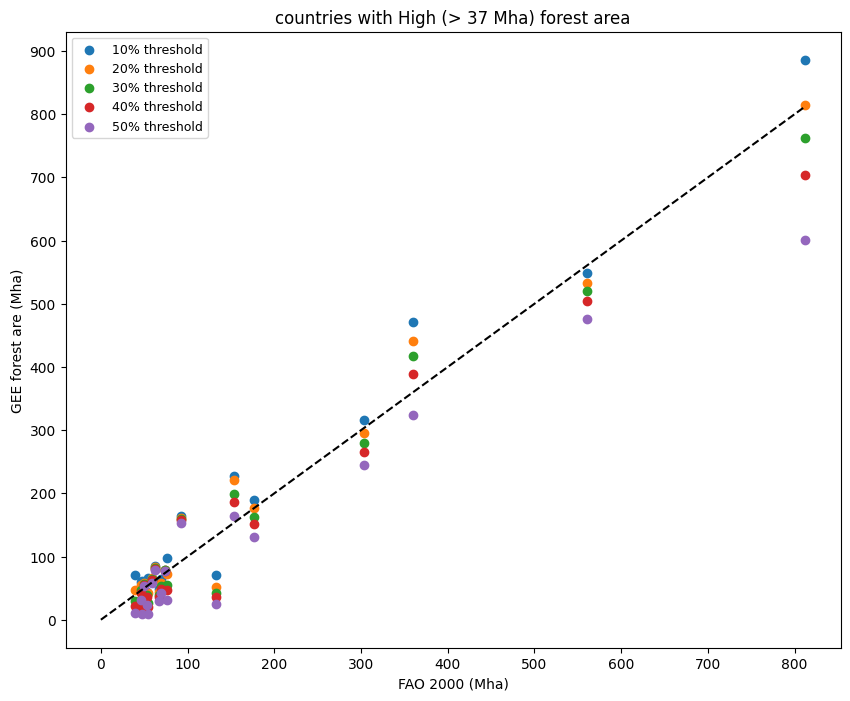

In [16]:

gee_fao_stats = []
bin_labels = ['Low (< 4 Mha)', 'Medium (4-37 Mha)', 'High (> 37 Mha)']
for bin_label in  bin_labels:
    fig, ax = plt.subplots(figsize=(10, 8))

    for threshold in country_thresholds:
        df = gee_fao_comparison_bins.groupby(['bin', 'threshold']).get_group((bin_label, threshold))
        x_values = df['FAO_2000_Mha'].dropna()
        y_values = df['area_Mha'].dropna()
        ax.scatter(x_values, y_values, label=f'{threshold}% threshold')
        ax.set_xlabel('FAO 2000 (Mha)')
        ax.set_ylabel('GEE forest are (Mha)')
        ax.set_title(f'countries with {bin_label} forest area')
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
        #print(f'in {bin_label} /n for threshold {threshold}%, R² = {r_value**2:.3f}, average deviation = {df["deviation_%"].median():.2f}%')
        gee_fao_stats.append({'bin': bin_label, 'threshold': threshold, 'r_squared': round(r_value**2, 3), 'average deviation': round(df["deviation_%"].median(), 1)})


    match_max=max(df['FAO_2000_Mha'])
    ax.plot([0, match_max], [0,match_max], linestyle = '--', color = 'black')

    ax.legend(fontsize = 9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))


gee_fao_stats_df = pd.DataFrame(gee_fao_stats)

print(gee_fao_stats_df)

['Africa' 'Americas' 'Asia and the Pacific' 'Europe' 'Near East']
                  region  threshold  region_total_forest_area  FAO_2000_Mha  \
0                 Africa         10               1025.563920       730.724   
5               Americas         10               1880.336278      1714.388   
10  Asia and the Pacific         10                759.156734       704.436   
15                Europe         10               1110.154331      1009.326   
20             Near East         10                 30.702769        60.208   

    deviation_Mha  deviation_%  
0      294.839920    40.349013  
5      165.948278     9.679739  
10      54.720734     7.768021  
15     100.828331     9.989669  
20     -29.505231    49.005500  
                  region  threshold  region_total_forest_area  FAO_2000_Mha  \
1                 Africa         20                742.245659       730.724   
6               Americas         20               1800.203346      1714.388   
11  Asia and the Pacific

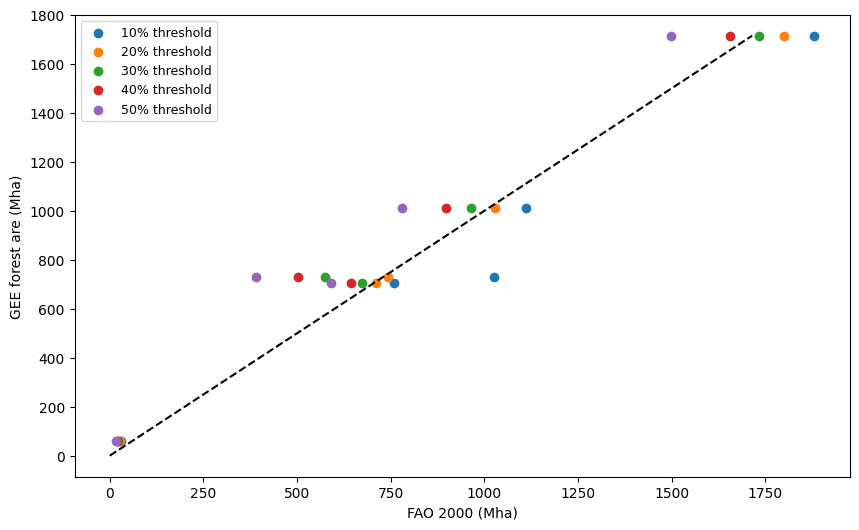

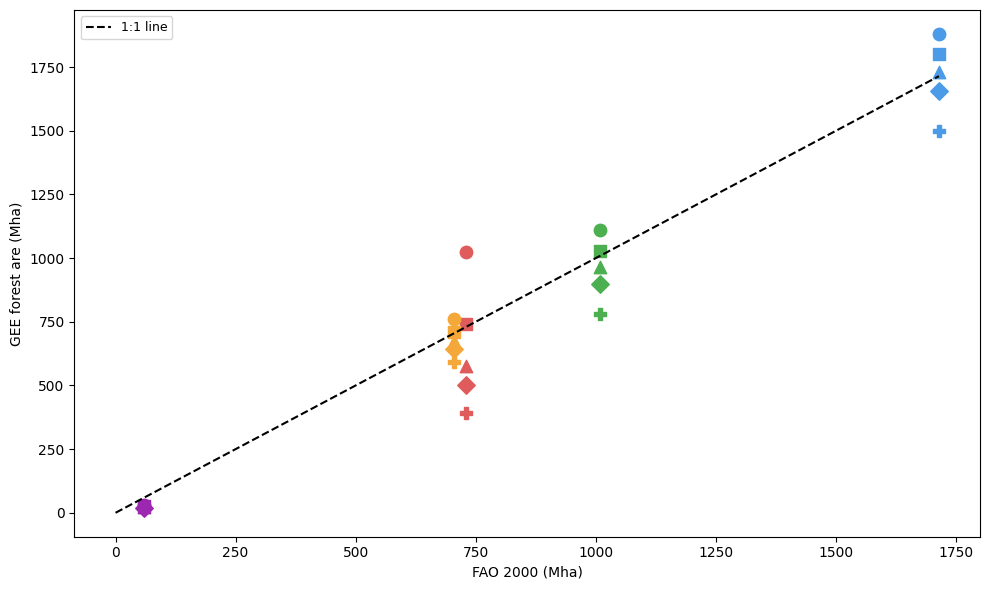

In [17]:
#from figures try to extact the best threshold

nb_region = gee_fao_comparison_region['region'].nunique()
regions = gee_fao_comparison_region['region'].unique()
print(gee_fao_comparison_region['region'].unique())

region_colors = {
    'Africa': '#E05C5C',
    'Americas': '#4C9BE8',
    'Asia and the Pacific': '#F4A83A',
    'Europe': '#4CAF50',
    'Near East': '#9C27B0'
}

threshold_markers = {
    10: 'o',   # circle
    20: 's',   # square
    30: '^',   # triangle
    40: 'D',   # diamond
    50: 'P'    # plus
}

fig, ax = plt.subplots(figsize=(10, 6))

for threshold in country_thresholds:
  df = gee_fao_comparison_region[gee_fao_comparison_region['threshold'] == threshold]
  x_values = df['region_total_forest_area']
  y_values = df['FAO_2000_Mha']
  ax.scatter(x_values, y_values, label=f'{threshold}% threshold')
  print(df)

ax.set_xlabel('FAO 2000 (Mha)')
ax.set_ylabel('GEE forest are (Mha)')
ax.legend(fontsize = 9)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
match_max=max(gee_fao_comparison_region['FAO_2000_Mha'])

ax.plot([0, match_max], [0,match_max], linestyle = '--', color = 'black')

#show the plot
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

for region in regions:
    for threshold in country_thresholds:
        df = gee_fao_comparison_region[
            (gee_fao_comparison_region['region'] == region) &
            (gee_fao_comparison_region['threshold'] == threshold)
        ]
        ax.scatter(df['FAO_2000_Mha'], df['region_total_forest_area'],
                   color=region_colors[region],
                   marker=threshold_markers[threshold],
                   s=80)

match_max = max(gee_fao_comparison_region['FAO_2000_Mha'])
ax.plot([0, match_max], [0, match_max], linestyle='--', color='black', label='1:1 line')
ax.set_xlabel('FAO 2000 (Mha)')
ax.set_ylabel('GEE forest area (Mha)')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel('FAO 2000 (Mha)')
ax.set_ylabel('GEE forest are (Mha)')
ax.legend(fontsize = 9)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
match_max=max(gee_fao_comparison_region['FAO_2000_Mha'])

plt.tight_layout()
plt.show()

for threshold 10%, R² = 0.980, average deviation = 38.70%
for threshold 20%, R² = 0.978, average deviation = 35.77%
for threshold 30%, R² = 0.977, average deviation = 34.54%
for threshold 40%, R² = 0.974, average deviation = 34.87%
for threshold 50%, R² = 0.965, average deviation = 34.76%


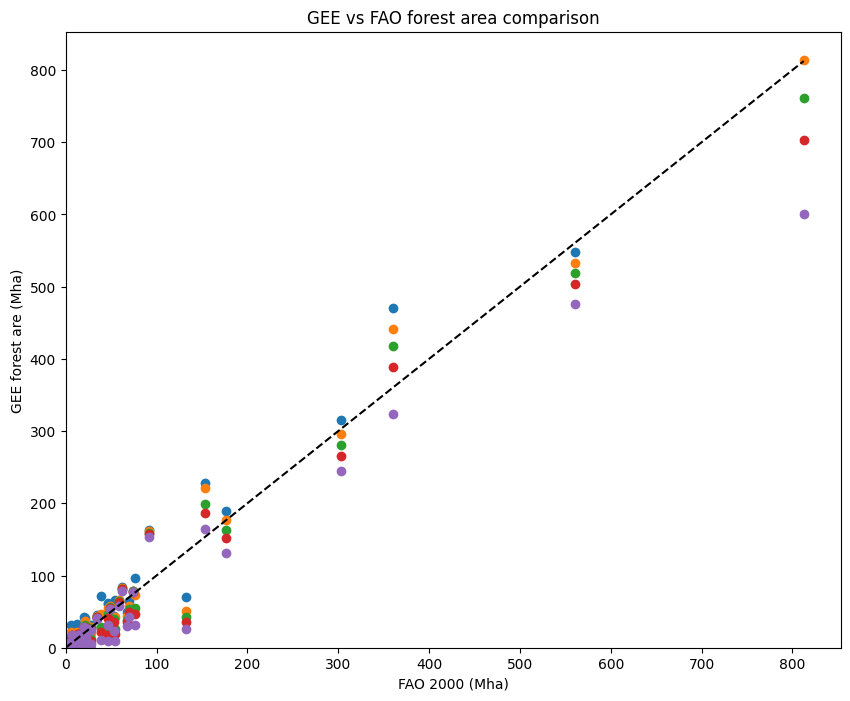

In [18]:
# ── CELL 8: plot GEE vs FAO. ──────────────
#create the figure and axes


fig, ax = plt.subplots(figsize=(10, 8))
plt.xlim(right = 1.05 *max(gee_fao_comparison['FAO_2000_Mha']))
plt.ylim(top = 1.05 *max(gee_fao_comparison['FAO_2000_Mha']))

#plot the dots
for threshold in country_thresholds:
  df =gee_fao_comparison[gee_fao_comparison['threshold'] == threshold]
  cleandev_df= clean_dev[clean_dev['threshold'] == threshold]
  x_values = df['FAO_2000_Mha'].dropna()   #check where are the nan in both column
  y_values = df['area_Mha'].dropna()

  ax.scatter(x_values, y_values, label='GEE 10%')
  slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
  print(f'for threshold {threshold}%, R² = {r_value**2:.3f}, average deviation = {cleandev_df["deviation_%"].median():.2f}%')




#add labels, limit and title
ax.set_xlabel('FAO 2000 (Mha)')
ax.set_ylabel('GEE forest are (Mha)')
ax.set_title('GEE vs FAO forest area comparison')

match_max=max(gee_fao_comparison['FAO_2000_Mha'])

ax.plot([0, match_max], [0,match_max], linestyle = '--', color = 'black')

#show the plot
plt.show()

In [19]:
# ── push results to GitHub ────────────────────────────────
import subprocess

# ask for PAT only if not already defined
if 'PAT' not in globals():
    import getpass
    PAT = getpass.getpass('Enter PAT: ')

%cd /content/Biochar_forest_estimation/
!git add .
!git commit -m "update results"

result = subprocess.run(
    f'git push https://{PAT}@github.com/MElsdk-lab/Biochar_forest_estimation.git main',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print('✅ Pushed to GitHub')
else:
    print('❌ Push failed')
    print(result.stderr)

Enter PAT: ··········
/content/Biochar_forest_estimation
[main 76fb05b] update results
 8 files changed, 38 insertions(+), 38 deletions(-)
 rewrite data/gee_fao_comparison_world.csv (82%)
✅ Pushed to GitHub
